# Our Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from kielmat.modules.gsd import ParaschivIonescuGaitSequenceDetection
from kielmat.modules.icd import ParaschivIonescuInitialContactDetection
from kielmat.config import cfg_colors

# 1. Get the absolute directory of the current script
script_dir = Path.cwd()

# 2. Build the path to the data folder
# This goes one level up (..), then into the 'data' folder
data_dir = (script_dir / ".." / "data" / "data_set" / "courseA" / "id01").resolve()

# 3. Create a path to a specific file inside that data folder
file_path = data_dir / "xsens.csv"

# print(f"Data directory: {data_dir}")
# print(f"File path: {file_path}")

data = pd.read_csv(file_path)

sampling_frequency = 60 # 6 recordings in 100 ms -> 60 recordings per second

# print(data['acceleration_Pelvis_x'])

#['acceleration_Pelvis_x']

Data directory: C:\Users\theil\Documents\0_summer2026\0_git\IMU-foot-strike-detection\data\data_set\courseA\id01
File path: C:\Users\theil\Documents\0_summer2026\0_git\IMU-foot-strike-detection\data\data_set\courseA\id01\xsens.csv
0       -3.558701
1       -3.475930
2       -1.969406
3        0.341094
4       -0.749699
           ...   
41475   -1.472593
41476   -1.700132
41477   -1.207494
41478   -0.109340
41479    0.261701
Name: acceleration_Pelvis_x, Length: 41480, dtype: float64


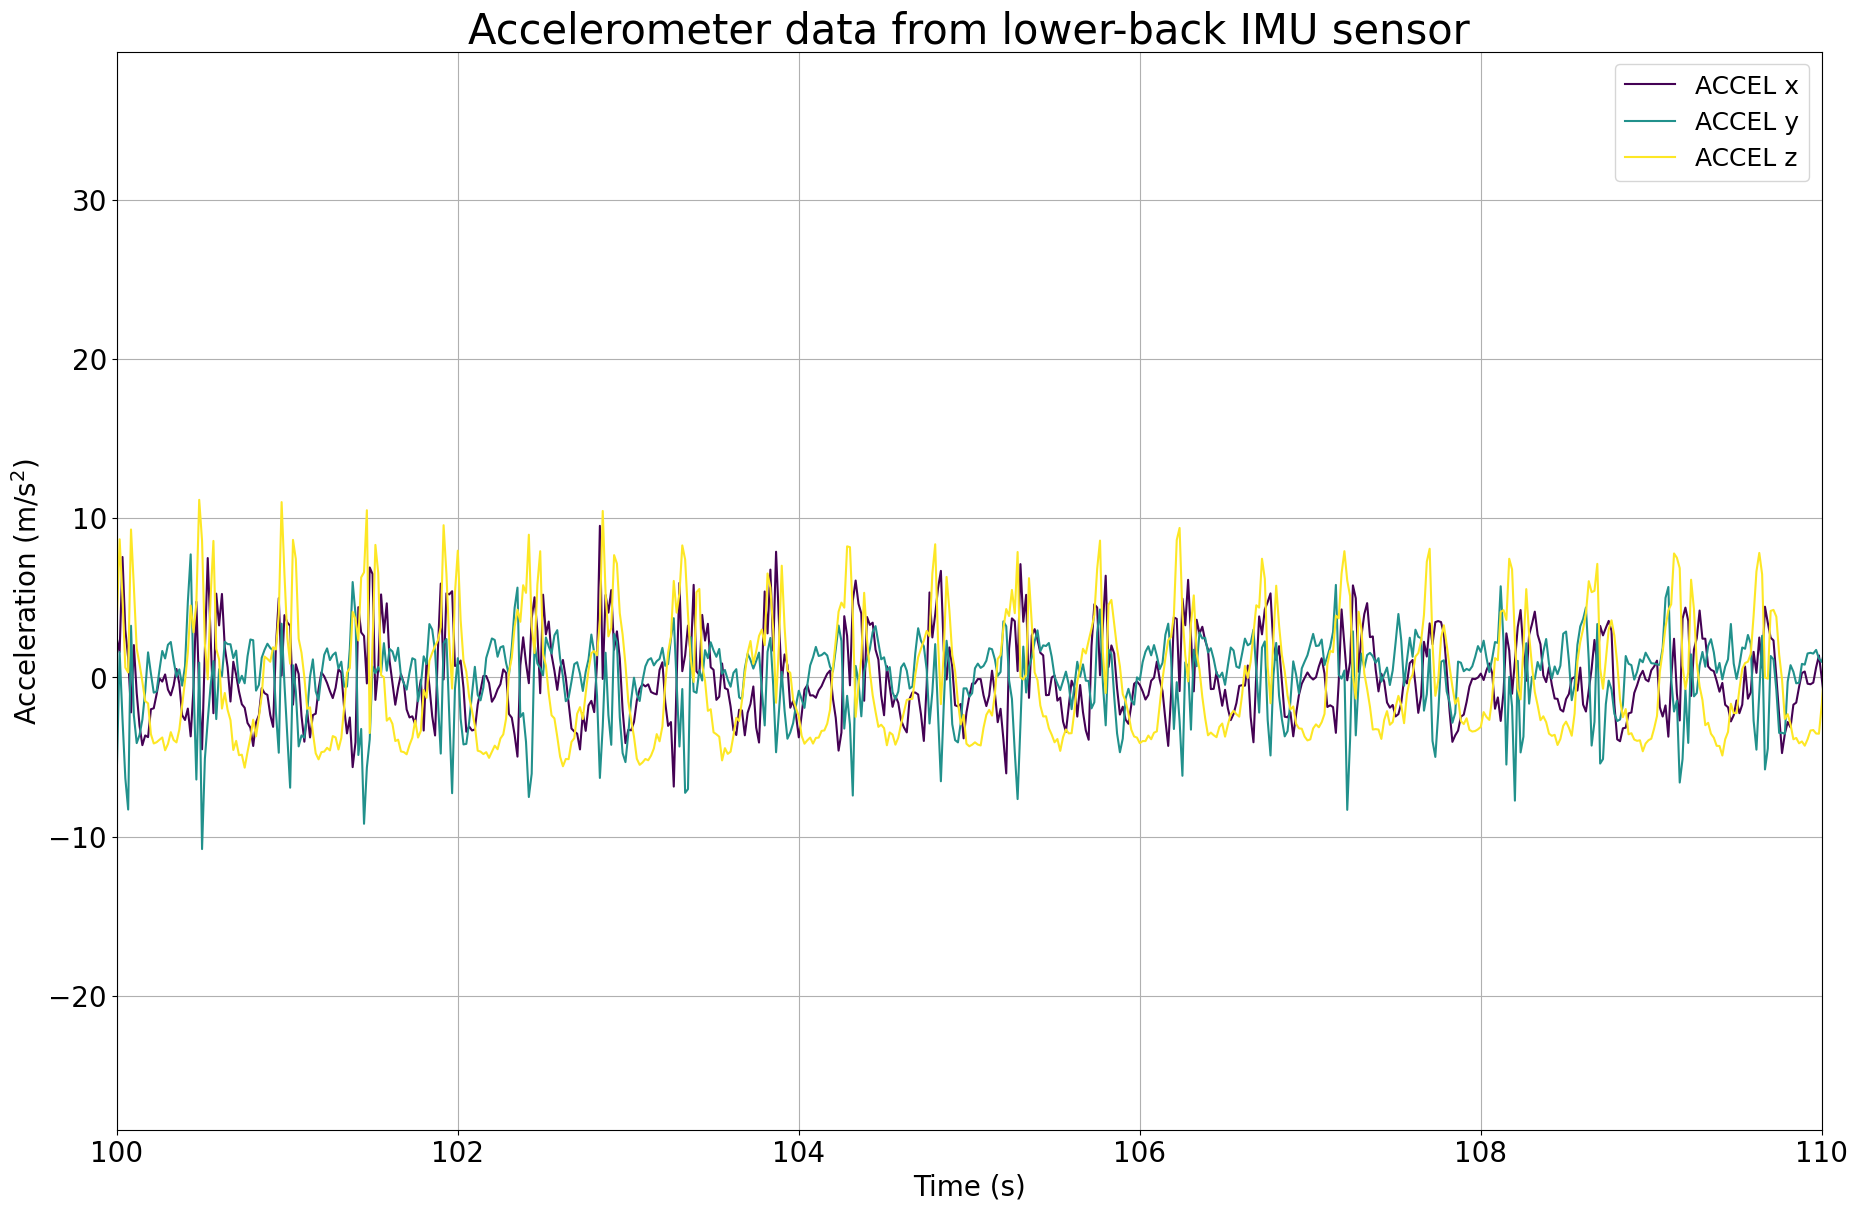

In [3]:
# Calculate the time values
acceleration_data =  data[['acceleration_Pelvis_x', 'acceleration_Pelvis_y', 'acceleration_Pelvis_z']]

time = np.arange(len(acceleration_data)) / (sampling_frequency)

# Create a figure with a specified size
plt.figure(figsize=(22, 14))

# Get colors for raw
colors = cfg_colors["raw"]

# A loop is used to plot data for each accelerometer axis, applying different colors from the color map.
for i in range(3):
    plt.plot(
        time,
        acceleration_data.iloc[:,i],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Add labels and legends
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
plt.legend(fontsize=18)

# Add a title with a specified font size
plt.title(
    "Accelerometer data from lower-back IMU sensor",
    fontsize=30,
)

# Customize tick font sizes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")
plt.xlim(100,110)

# Show the plot
plt.show()

In [ ]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect to detect gait sequences
gsd = gsd.detect(
    acceleration_data, 
    sampling_frequency
)

# Gait sequences are stored in gait_sequences_ attribute of gsd
gait_sequences = gsd.gait_sequences_

# print(gait_sequences)

# Now, use Paraschiv-Ionescu initial contact detection algortihm to find initial contacts within detected gait sequences.
icd = ParaschivIonescuInitialContactDetection()

# Call the initial contact detection using icd.detect
icd = icd.detect(
    acceleration_data,
    sampling_frequency,
    "acceleration_Pelvis_z"
)

# Print initial contacts information
print(type(icd.initial_contacts_['onset'].to_numpy()*1000))
print(icd.initial_contacts_['onset'].to_numpy().reshape(-1,1)*1000)

2 gait sequence(s) detected.
<class 'numpy.ndarray'>
[[4.25000e+02]
 [9.50000e+02]
 [1.47500e+03]
 ...
 [6.89375e+05]
 [6.89925e+05]
 [6.90550e+05]]


First Gait Sequence: onset                        0.0
duration                  251.35
event_type         gait sequence
tracking_system             None
Name: 0, dtype: object


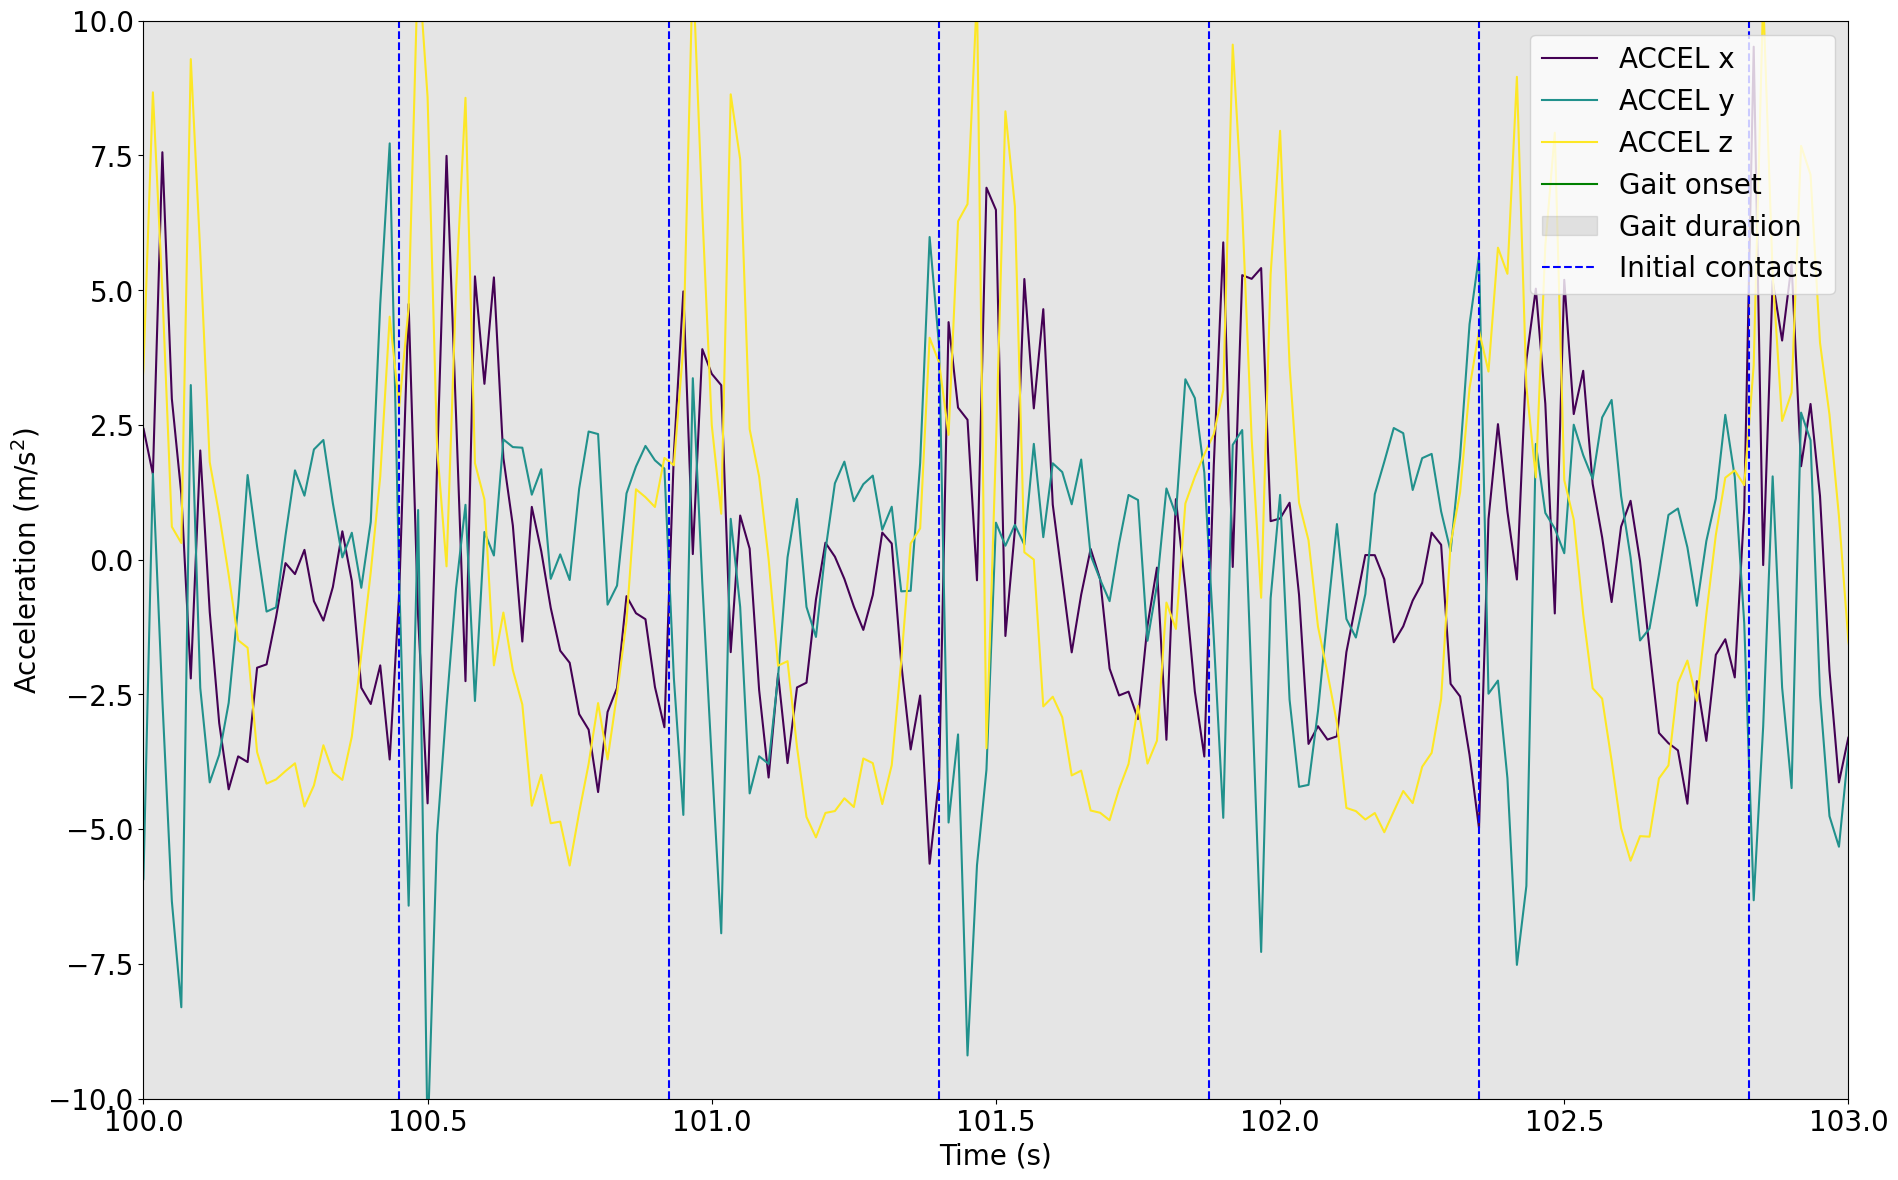

In [7]:
# Access the first detected gait sequence
first_gait_sequence = gsd.gait_sequences_[gsd.gait_sequences_["event_type"] == "gait sequence"].iloc[0]

# Print information about the first gait sequence
print("First Gait Sequence:", first_gait_sequence)

# Print information about initial contacts within the first gait sequence
ic_within_gait = icd.initial_contacts_[
    icd.initial_contacts_["onset"].between(
        first_gait_sequence["onset"],
        first_gait_sequence["onset"] + first_gait_sequence["duration"],
    )
]

# Plot the raw data from the lower back
fig, ax = plt.subplots(figsize=(22, 14))

# Plot raw acceleration data
for i in range(3):
    ax.plot(
        time,
        acceleration_data.iloc[:,i],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Plot the first element of gait sequences
plt.axvline(first_gait_sequence["onset"], color="g", label="Gait onset")
ax.axvspan(
    first_gait_sequence["onset"],
    first_gait_sequence["onset"] + first_gait_sequence["duration"],
    alpha=0.2,
    color="gray",
    label="Gait duration",
)

# Plot the initial contacts within the first gait sequence
for ic_time in ic_within_gait["onset"]:
    ax.axvline(ic_time, color="blue", linestyle="--")

# Customize plot
start_limit = first_gait_sequence["onset"] - 1
end_limit = first_gait_sequence["onset"] + first_gait_sequence["duration"] + 1
ax.set_xlim(start_limit, end_limit)
ax.set_xlabel("Time (s)", fontsize=20)
ax.set_ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
ax.set_xlim(100,103)
ax.set_ylim(-10,10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.legend(
    ["ACCEL x", "ACCEL y", "ACCEL z", "Gait onset", "Gait duration", "Initial contacts"],
    fontsize=20,
    loc="upper right",
)
plt.show()